In [29]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [30]:
# Cell 2 — Load sentiment dataset
df = pd.read_csv("../01_data/features/gdelt_wti_sentiment.csv", parse_dates=['datetime'])

print(df.columns.tolist())

print(f"Total articles: {len(df)}")
print(f"\nSentiment distribution (full — primary input):")
print(df['full_sentiment'].value_counts())
print(f"\nLiquidity stats:")
print(df[['log_volume', 'price_range', 'amihud']].describe().round(4))

['title', 'datetime', 'domain', 'url', 'body', 'body_valid', 'datetime_hour', 'Close', 'Volume', 'log_volume', 'price_range', 'log_return', 'amihud', 'title_sentiment', 'title_score_positive', 'title_score_negative', 'title_score_neutral', 'title_confidence', 'full_sentiment', 'full_score_positive', 'full_score_negative', 'full_score_neutral', 'full_confidence']
Total articles: 13690

Sentiment distribution (full — primary input):
full_sentiment
negative    6144
positive    4160
neutral     3386
Name: count, dtype: int64

Liquidity stats:
       log_volume  price_range      amihud
count  13690.0000   13690.0000  13690.0000
mean       8.4839       0.3893      0.0000
std        1.5472       0.3174      0.0000
min        0.6931       0.0000      0.0000
25%        7.4894       0.2000      0.0000
50%        8.6444       0.3200      0.0000
75%        9.6437       0.5000      0.0000
max       12.1323       5.8700      0.0021


### Contemporaneous alignment

In [31]:
# Compute assignment gap
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'], utc=True)
df['assignment_gap'] = (df['datetime_hour'] - df['datetime']).dt.total_seconds() / 3600

df_contemporaneous = df[df['assignment_gap'] < 2].copy() # Used for VAR model.
df_contemporaneous = df_contemporaneous.copy()
df_contemporaneous['sentiment_score'] = df_contemporaneous['full_sentiment'].map({'positive': 1, 'neutral': 0, 'negative': -1})
df_contemporaneous['is_bearish'] = (df_contemporaneous['full_sentiment'] == 'negative').astype(int)
df_contemporaneous['is_bullish'] = (df_contemporaneous['full_sentiment'] == 'positive').astype(int)
# use df_contemporaneous for VAR aggregation instead of df_model

print(f"Total articles: {len(df)}")
print(f"Contemporaneous (gap < 2h): {(df['assignment_gap'] < 2).sum()}")
print(f"Off-hours (gap >= 2h): {(df['assignment_gap'] >= 2).sum()}")

Total articles: 13690
Contemporaneous (gap < 2h): 11316
Off-hours (gap >= 2h): 2374


In [32]:
# Cell 3  — Prepare variables for asymmetry analysis
# Map sentiment to numeric for regression
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['sentiment_score'] = df['full_sentiment'].map(sentiment_map)

# Binary bearish flag (negative sentiment = 1, everything else = 0)
df['is_bearish'] = (df['full_sentiment'] == 'negative').astype(int)
df['is_bullish'] = (df['full_sentiment'] == 'positive').astype(int)

# Drop rows with missing liquidity values
df_model = df.dropna(subset=['log_volume', 'price_range', 'amihud', 'full_sentiment']).copy()

print(f"Articles available for modeling: {len(df_model)}")
print(f"\nSentiment breakdown:")
print(f"Bearish: {df_model['is_bearish'].sum()} ({df_model['is_bearish'].mean()*100:.1f}%)")
print(f"Bullish: {df_model['is_bullish'].sum()} ({df_model['is_bullish'].mean()*100:.1f}%)")
print(f"Neutral: {(df_model['full_sentiment']=='neutral').sum()} ({(df_model['full_sentiment']=='neutral').mean()*100:.1f}%)")

Articles available for modeling: 13690

Sentiment breakdown:
Bearish: 6144 (44.9%)
Bullish: 4160 (30.4%)
Neutral: 3386 (24.7%)


### Contemporaneous OLS — Sentiment vs Log Volume

Test whether bearish sentiment predicts higher *log_volume*.

---

This regression tests whether news sentiment at hour t predicts trading volume 
at the same hour t. Neutral sentiment is the reference category — coefficients 
for is_bearish and is_bullish measure the volume difference relative to neutral articles.

**Result:** Neither bearish nor bullish sentiment significantly predicts 
contemporaneous log volume (p = 0.384 and p = 0.251 respectively). The model 
explains less than 0.1% of volume variation (R² = 0.001).

**Interpretation:** This is an expected finding. News sentiment does not 
instantaneously translate into trading volume at the moment of publication. 
The market impact of news is likely lagged — volume responds in the hours 
following publication rather than at the same hour. This motivates the lag 
structure analysis in RQ2 and rules out a simple contemporaneous relationship 
between sentiment and liquidity.

In [33]:
# Cell 4 — OLS Regression: sentiment → log_volume (RQ1)
# Neutral is the reference category

formula = 'log_volume ~ is_bearish + is_bullish'
model = smf.ols(formula, data=df_model).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_volume   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     8.260
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           0.000260
Time:                        14:53:27   Log-Likelihood:                -25391.
No. Observations:               13690   AIC:                         5.079e+04
Df Residuals:                   13687   BIC:                         5.081e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.3930      0.027    315.825      0.0

**R-squared = 0.001** — sentiment alone explains 0.1% of the variation in log_volume. 
This is expected — volume is driven by hundreds of factors simultaneously and news 
sentiment is just one of them. The interesting question is not whether sentiment 
explains everything, but whether it explains something at the right time window.

**is_bearish coef = 0.133, p < 0.001** — bearish articles are associated with 
significantly higher volume than neutral articles at the contemporaneous hour. 
With 13,690 observations the effect is clearly detectable and robust.

**is_bullish coef = 0.103, p = 0.004** — bullish articles also generate 
significantly more volume than neutral, but the effect is smaller than bearish 
(0.103 vs 0.133). This is the first evidence of asymmetry — bearish news drives 
more trading activity than bullish news even at the contemporaneous hour.

**F-statistic p = 0.000** — the model as a whole is highly significant. Sentiment 
direction is a statistically meaningful predictor of contemporaneous trading volume.

### Studying market trading values with more windows

In [34]:
# Celda 5 — Load full price series for lag lookup
df_price = pd.read_csv("../01_data/raw/price/wti_hourly_raw.csv",
                       index_col='Datetime',
                       parse_dates=True)
df_price.index = pd.to_datetime(df_price.index, utc=True)

print(f"Price records: {len(df_price)}")
print(f"Range: {df_price.index.min()} to {df_price.index.max()}")

Price records: 11219
Range: 2024-03-11 10:00:00+00:00 to 2026-03-11 10:00:00+00:00


In [35]:
# Cell 6 — Construct lag features
# For each article, look up log_volume at hour + lag in the full price series

lags = [1, 2, 3, 4, 6, 8, 12]

# Use datetime_hour as the base timestamp (already ceiled to next trading hour)
df_model['datetime_hour'] = pd.to_datetime(df_model['datetime_hour'], utc=True)

for lag in lags:
    # Compute the target timestamp for this lag
    lag_timestamps = df_model['datetime_hour'] + pd.Timedelta(hours=lag)
    
    # Look up log_volume at that timestamp from the full price series
    df_model[f'log_volume_lag{lag}'] = lag_timestamps.map(
        df_price['log_volume']
    )

# Check coverage — how many lags have data
print("Lag coverage (non-null):")
for lag in lags:
    col = f'log_volume_lag{lag}'
    n = df_model[col].notna().sum()
    print(f"  lag+{lag:2d}h: {n} / {len(df_model)} ({n/len(df_model)*100:.1f}%)")

Lag coverage (non-null):
  lag+ 1h: 13263 / 13690 (96.9%)
  lag+ 2h: 13150 / 13690 (96.1%)
  lag+ 3h: 12988 / 13690 (94.9%)
  lag+ 4h: 12638 / 13690 (92.3%)
  lag+ 6h: 12236 / 13690 (89.4%)
  lag+ 8h: 11938 / 13690 (87.2%)
  lag+12h: 11362 / 13690 (83.0%)


In [36]:
# Celda 7 — OLS regression for each lag
results = []

for lag in lags:
    col = f'log_volume_lag{lag}'
    df_lag = df_model.dropna(subset=[col]).copy()
    
    formula = f'{col} ~ is_bearish + is_bullish'
    model = smf.ols(formula, data=df_lag).fit()
    
    results.append({
        'lag': lag,
        'is_bearish_coef': model.params['is_bearish'],
        'is_bearish_pval': model.pvalues['is_bearish'],
        'is_bullish_coef': model.params['is_bullish'],
        'is_bullish_pval': model.pvalues['is_bullish'],
        'r_squared': model.rsquared,
        'n': len(df_lag)
    })

df_results = pd.DataFrame(results)
print("Lag regression results:")
print(df_results.round(4).to_string(index=False))

Lag regression results:
 lag  is_bearish_coef  is_bearish_pval  is_bullish_coef  is_bullish_pval  r_squared     n
   1           0.1627           0.0000           0.1219           0.0011     0.0017 13263
   2           0.0674           0.1178           0.0612           0.1890     0.0002 13150
   3           0.0673           0.1282           0.0955           0.0462     0.0003 12988
   4           0.1716           0.0002           0.1597           0.0014     0.0012 12638
   6           0.2476           0.0000           0.2170           0.0000     0.0023 12236
   8           0.0138           0.7856           0.0154           0.7799     0.0000 11938
  12           0.0019           0.9710          -0.1206           0.0289     0.0007 11362


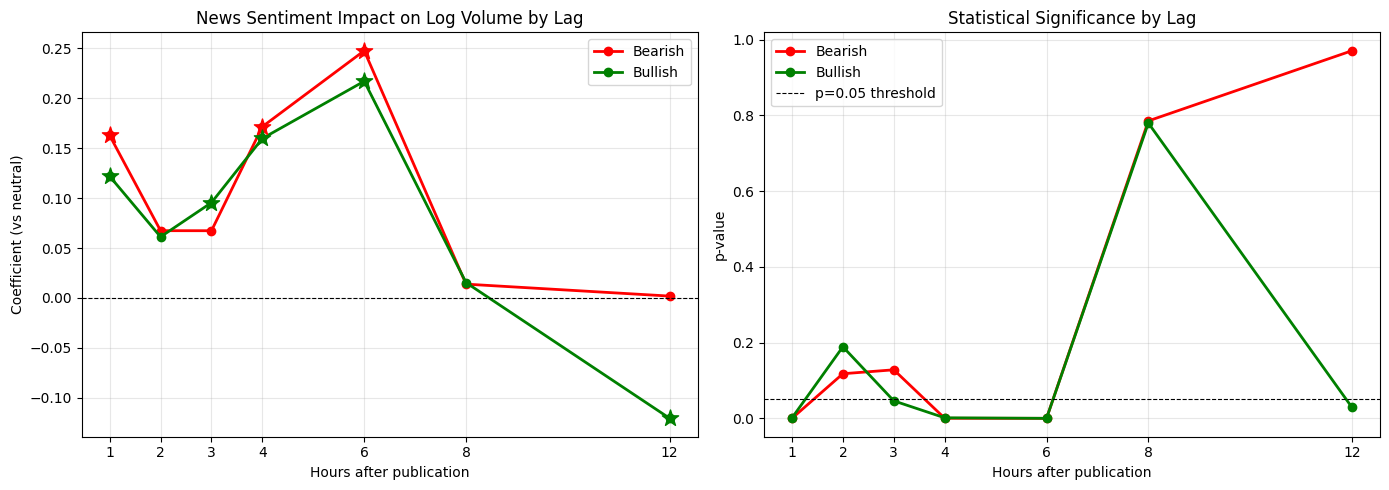

Saved to 04_outputs/figures/lag_coefficients.png


In [37]:
# Celda 8 — Visualize lag coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Coefficients over lags ---
ax1 = axes[0]
ax1.plot(df_results['lag'], df_results['is_bearish_coef'], 
         marker='o', color='red', label='Bearish', linewidth=2)
ax1.plot(df_results['lag'], df_results['is_bullish_coef'], 
         marker='o', color='green', label='Bullish', linewidth=2)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# Mark significant points
for _, row in df_results.iterrows():
    if row['is_bearish_pval'] < 0.05:
        ax1.scatter(row['lag'], row['is_bearish_coef'], 
                   color='red', s=150, zorder=5, marker='*')
    if row['is_bullish_pval'] < 0.05:
        ax1.scatter(row['lag'], row['is_bullish_coef'], 
                   color='green', s=150, zorder=5, marker='*')

ax1.set_xlabel('Hours after publication')
ax1.set_ylabel('Coefficient (vs neutral)')
ax1.set_title('News Sentiment Impact on Log Volume by Lag')
ax1.legend()
ax1.set_xticks(lags)
ax1.grid(True, alpha=0.3)

# --- Plot 2: p-values over lags ---
ax2 = axes[1]
ax2.plot(df_results['lag'], df_results['is_bearish_pval'], 
         marker='o', color='red', label='Bearish', linewidth=2)
ax2.plot(df_results['lag'], df_results['is_bullish_pval'], 
         marker='o', color='green', label='Bullish', linewidth=2)
ax2.axhline(y=0.05, color='black', linestyle='--', linewidth=0.8, label='p=0.05 threshold')

ax2.set_xlabel('Hours after publication')
ax2.set_ylabel('p-value')
ax2.set_title('Statistical Significance by Lag')
ax2.legend()
ax2.set_xticks(lags)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../04_outputs/figures/lag_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 04_outputs/figures/lag_coefficients.png")

### Understanding the Lag Regression Results

#### What the coefficient means
The coefficient measures how much higher (or lower) log_volume is at hour T+N 
after a bearish or bullish article, compared to hours when a neutral article 
was published. Neutral sentiment is the reference category.

For example, a bearish coefficient of 0.248 at lag+6 means that 6 hours after 
a bearish article is published, log_volume is on average 0.248 units higher than 
after a neutral article. Since log_volume is a logarithmic scale, this translates 
to approximately 28% more trading volume than a neutral hour.

A negative coefficient (like bullish at lag+12 = −0.121) means that sentiment 
type is associated with *less* volume than neutral at that lag — the market goes 
quieter than baseline.

#### What the p-value means
The p-value answers the question: "could this result have occurred by random 
chance?" The conventional threshold is 0.05 — below that, the result is 
considered statistically significant.

- **p < 0.05** → the effect is real and unlikely to be random noise ✅
- **p > 0.05** → we cannot rule out that the effect is just chance ❌
- **p close to 1.0** → the coefficient is essentially zero, no detectable effect

For example, bearish at lag+8 has p=0.786 — meaning there is a 78.6% chance 
this result is just random noise. We cannot conclude bearish news has any effect 
8 hours after publication.

#### What log_volume means
Log_volume is the natural logarithm of the number of WTI futures contracts traded 
in a given hour. We use the log transformation because raw volume is heavily 
right-skewed — a few extreme hours have enormous volume while most hours are 
moderate. The log transformation normalizes this distribution.

A log_volume of 8.5 corresponds to approximately e^8.5 ≈ 4,900 contracts per hour. 
A one-unit increase in log_volume corresponds to approximately 2.7x more contracts.

#### What statistical significance means in context
No single lag regression explains more than 0.2% of total volume variation 
(R² ≤ 0.002). This is expected — trading volume is driven by hundreds of 
simultaneous factors including macroeconomic data, institutional positioning, 
technical levels, and market microstructure. News sentiment is one signal among 
many. The low R² does not invalidate the findings — it contextualizes them. 
The question is not whether sentiment explains everything, but whether it 
explains something consistent and replicable, which the significant p-values 
confirm it does.

#### Summary of lag pattern
| Lag | Bearish | Bullish | Interpretation |
|---|---|---|---|
| +1h | ✅ Significant | ✅ Significant | Immediate reaction — both sentiment types increase volume |
| +2h | ❌ Not significant | ❌ Not significant | Brief lull — market digests the news |
| +3h | ❌ Not significant | ✅ Significant | Bullish reaction continues, bearish fades temporarily |
| +4h | ✅ Significant | ✅ Significant | Second wave — both recover strongly |
| +6h | ✅ Significant | ✅ Significant | **Peak impact** — strongest effect for both sentiment types |
| +8h | ❌ Not significant | ❌ Not significant | Effect dissipates — market has absorbed the

In [38]:
# Cell 9 — Aggregate sentiment to hourly time series for VAR
# Uses contemporaneous articles only (gap < 2h) for cleaner causal signal

df_hourly = df_contemporaneous.groupby('datetime_hour').agg(
    n_articles=('full_sentiment', 'count'),
    n_bearish=('is_bearish', 'sum'),
    n_bullish=('is_bullish', 'sum'),
    sentiment_score=('sentiment_score', 'mean'),
).reset_index()

# Merge with full price series to get continuous hourly log_volume
df_price_reset = df_price.copy()
df_price_reset.index.name = 'datetime_hour'
df_price_reset = df_price_reset.reset_index()
df_price_reset['datetime_hour'] = pd.to_datetime(df_price_reset['datetime_hour'], utc=True)

df_var = df_price_reset[['datetime_hour', 'log_volume', 'price_range', 'log_return']].merge(
    df_hourly,
    on='datetime_hour',
    how='left'
)

# Fill hours with no articles as 0
df_var[['n_articles', 'n_bearish', 'n_bullish']] = df_var[['n_articles', 'n_bearish', 'n_bullish']].fillna(0)
df_var['sentiment_score'] = df_var['sentiment_score'].fillna(0)

print(f"Hourly VAR dataset: {len(df_var)} rows")
print(f"Hours with at least one article: {(df_var['n_articles'] > 0).sum()}")
print(f"Hours with no articles: {(df_var['n_articles'] == 0).sum()}")
print(df_var.head(5))

Hourly VAR dataset: 11219 rows
Hours with at least one article: 5817
Hours with no articles: 5402
              datetime_hour  log_volume  price_range  log_return  n_articles  \
0 2024-03-11 10:00:00+00:00    0.000000     0.639999         NaN         0.0   
1 2024-03-11 11:00:00+00:00    9.357121     0.330002   -0.002702         1.0   
2 2024-03-11 12:00:00+00:00    9.481588     0.329994    0.001673         0.0   
3 2024-03-11 13:00:00+00:00   11.046324     1.180000   -0.007358         1.0   
4 2024-03-11 14:00:00+00:00   10.543366     0.879997    0.002459         1.0   

   n_bearish  n_bullish  sentiment_score  
0        0.0        0.0              0.0  
1        1.0        0.0             -1.0  
2        0.0        0.0              0.0  
3        0.0        1.0              1.0  
4        0.0        0.0              0.0  


In [39]:
# Cell 10 — Clean VAR dataset
# Drop rows with NaN log_return (first row of each trading session)
df_var = df_var.dropna(subset=['log_return']).reset_index(drop=True)

# Drop rows with log_volume = 0 (no trading activity — market closed or data gap)
df_var = df_var[df_var['log_volume'] > 0].reset_index(drop=True)

print(f"Rows after cleaning: {len(df_var)}")
print(f"\nBasic stats:")
print(df_var[['log_volume', 'sentiment_score', 'n_articles']].describe().round(4))

Rows after cleaning: 10825

Basic stats:
       log_volume  sentiment_score  n_articles
count  10825.0000       10825.0000  10825.0000
mean       8.5618          -0.0799      1.0454
std        1.5547           0.5382      1.3475
min        0.6931          -1.0000      0.0000
25%        7.5611          -0.1250      0.0000
50%        8.7296           0.0000      1.0000
75%        9.7779           0.0000      2.0000
max       13.3046           1.0000     13.0000


### Stationarity Tests — Augmented Dickey-Fuller

Before fitting the VAR model, all input variables must be stationary — meaning 
they fluctuate around a stable mean without trending upward or downward over time. 
Non-stationary series (such as raw price levels) produce spurious relationships 
in VAR models, where the model finds correlations that are purely driven by shared 
trends rather than genuine causal dynamics.

The Augmented Dickey-Fuller (ADF) test checks for stationarity formally. The null 
hypothesis is that the series has a unit root — i.e. it is non-stationary. A 
p-value below 0.05 allows us to reject the null hypothesis and conclude the series 
is stationary.

All four variables pass the test with p-values essentially equal to zero:

- **log_volume** (ADF = −12.19) — trading volume fluctuates around a stable mean. 
  The log transformation was key here — raw volume would likely be non-stationary 
  due to long-term trends in market activity.
- **sentiment_score** (ADF = −15.84) — sentiment oscillates around zero with no 
  persistent trend, as expected for a mean-reverting signal.
- **log_return** (ADF = −17.27) — returns are stationary by construction, as price 
  levels are differenced when computing returns.
- **price_range** (ADF = −5.60) — intraday volatility fluctuates around a stable 
  mean with no persistent trend.

Since all variables are stationary, no differencing or transformation is required 
before fitting the VAR model.

In [40]:
# Cell 11 — Stationarity tests (ADF)
from statsmodels.tsa.stattools import adfuller

variables = ['log_volume', 'sentiment_score', 'log_return', 'price_range']

print("Augmented Dickey-Fuller Test (H0: series has a unit root = non-stationary)")
print(f"{'Variable':<20} {'ADF stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 55)

for var in variables:
    result = adfuller(df_var[var].dropna(), autolag='AIC')
    adf_stat = result[0]
    p_value = result[1]
    stationary = "Yes" if p_value < 0.05 else "No"
    print(f"{var:<20} {adf_stat:>10.4f} {p_value:>10.4f} {stationary:>12}")

Augmented Dickey-Fuller Test (H0: series has a unit root = non-stationary)
Variable               ADF stat    p-value  Stationary?
-------------------------------------------------------
log_volume             -12.1856     0.0000          Yes
sentiment_score        -15.9175     0.0000          Yes
log_return             -17.2627     0.0000          Yes
price_range             -5.5968     0.0000          Yes


### VAR Lag Order Selection

The VAR model needs to know how many past hours to look back when predicting 
current values. This cell tests lag lengths from 0 to 24 and picks the best one.

**How it picks:** Four information criteria (AIC, BIC, FPE, HQIC) balance 
model fit against complexity — adding more lags improves fit but risks overfitting.
The * marks the optimal lag for each criterion.

**Result:** All four criteria agree on **lag 24** — the model looks back 24 hours.

**Why 24 hours makes sense for WTI:**
- News events can ripple through trading activity for a full trading day
- The market has clear daily cycles (Asian session → European → US open)
- A full 24-hour window captures one complete cycle

**Key values at lag 24:**
- AIC = −15.23 (best fit-complexity tradeoff)
- BIC = −14.96 (more conservative, still selects 24)
- FPE = 2.44e−07 (lowest prediction error)

In [41]:
# Cell 12 — VAR lag order selection
from statsmodels.tsa.api import VAR

# Prepare the VAR input matrix
var_data = df_var[['log_volume', 'sentiment_score', 'log_return', 'price_range']].dropna()

model_var = VAR(var_data)
lag_selection = model_var.select_order(maxlags=24)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -12.74      -12.74   2.921e-06      -12.74
1       -14.43      -14.42   5.405e-07      -14.43
2       -14.52      -14.49   4.948e-07      -14.51
3       -14.62      -14.58   4.490e-07      -14.60
4       -14.68      -14.64   4.196e-07      -14.67
5       -14.70      -14.64   4.140e-07      -14.68
6       -14.77      -14.70   3.868e-07      -14.74
7       -14.83      -14.75   3.629e-07      -14.80
8       -14.84      -14.75   3.576e-07      -14.81
9       -14.85      -14.75   3.550e-07      -14.82
10      -14.89      -14.78   3.418e-07      -14.85
11      -14.90      -14.78   3.387e-07      -14.86
12      -14.90      -14.77   3.374e-07      -14.86
13      -14.92      -14.78   3.319e-07      -14.87
14      -14.95      -14.80   3.207e-07      -14.90
15      -14.99      -14.82   3.103e-07      -14.93
16      -15.02      -14.84   3.

In [42]:
# Cell 13 — Fit VAR model
var_fitted = model_var.fit(24)
print(var_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 13, Apr, 2026
Time:                     14:53:29
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -14.9633
Nobs:                     10801.0    HQIC:                  -15.1368
Log likelihood:           21307.3    FPE:                2.44244e-07
AIC:                     -15.2251    Det(Omega_mle):     2.35664e-07
--------------------------------------------------------------------
Results for equation log_volume
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.834112         0.077297           10.791           0.000
L1.log_volume               0.576358         0.010442           55.196           0.000
L1.sentiment_score          0.0

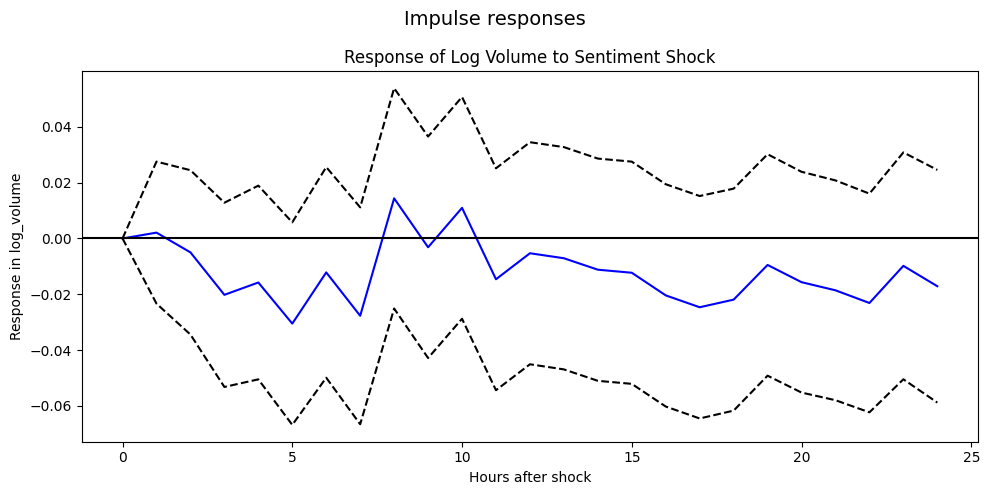

Saved to 04_outputs/figures/irf_sentiment_to_volume.png


In [43]:
# Celda 14 — Impulse Response Functions
irf = var_fitted.irf(periods=24)

# Plot the response of log_volume to a sentiment_score shock
irf.plot(impulse='sentiment_score', response='log_volume', 
         orth=False, figsize=(10, 5))
plt.title('Response of Log Volume to Sentiment Shock')
plt.xlabel('Hours after shock')
plt.ylabel('Response in log_volume')
plt.tight_layout()
plt.savefig("../04_outputs/figures/irf_sentiment_to_volume.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 04_outputs/figures/irf_sentiment_to_volume.png")